In [1]:
import numpy as np
import pickle
import os
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
base_path = r"C:\Users\syeda\OneDrive\Documents\Semester 4\Seminar Advances in Deep Learning for Time Series\project\OnHW-Words500_dep\Words500_dep_02\0"

In [3]:
def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

X_train = load_pkl(os.path.join(base_path, "all_x_dat_train_imu.pkl"))
y_train = load_pkl(os.path.join(base_path, "train_ids.pkl"))

X_val = load_pkl(os.path.join(base_path, "all_x_dat_val_imu.pkl"))
y_val = load_pkl(os.path.join(base_path, "val_ids.pkl"))

print("Train samples:", len(X_train))
print("Val samples:", len(X_val))

print("Example time-series shape:", X_train[0].shape)
print("Unique writer IDs:", np.unique(y_train))

Train samples: 20176
Val samples: 5042
Example time-series shape: (220, 13)
Unique writer IDs: [   0    1    2    3    5    6    7    8    9   10   11   12   13   14
   15   16   17   18 1001 1002 1003 1004 1005 1006 1007 1008 1009 1011
 1050 1051 1053 1054 1060 1061 1071 1072 1073 1080 1086 1090 2001 2002
 2003 2004 2005 2006 2007 4001 4002 4005 4006 4008 4009]


In [4]:
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_val_enc = encoder.transform(y_val)

num_classes = len(encoder.classes_)
print("Number of writers:", num_classes)
print("Example encoded labels:", y_train_enc[:20])

Number of writers: 53
Example encoded labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [5]:
print("X_train example shape:", X_train[0].shape)
print("X_val example shape:", X_val[0].shape)

X_train example shape: (220, 13)
X_val example shape: (206, 13)


In [6]:
print(type(X_train))
print(type(X_train[0]))
print(type(X_val))
print(type(X_val[0]))

<class 'list'>
<class 'numpy.ndarray'>
<class 'list'>
<class 'numpy.ndarray'>


In [7]:
max_len = 100  

def pad_or_truncate(data, max_len):
    processed = []
    for seq in data:
        seq = np.array(seq)

        # Truncate long sequences
        if len(seq) > max_len:
            seq = seq[:max_len]

        # Pad short sequences
        if len(seq) < max_len:
            pad_width = max_len - len(seq)
            padding = np.zeros((pad_width, seq.shape[1]))
            seq = np.vstack([seq, padding])

        processed.append(seq)

    return np.array(processed, dtype=np.float32)

X_train_pad = pad_or_truncate(X_train, max_len)
X_val_pad   = pad_or_truncate(X_val, max_len)

print("Train padded shape:", X_train_pad.shape)
print("Val padded shape:", X_val_pad.shape)

Train padded shape: (20176, 100, 13)
Val padded shape: (5042, 100, 13)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

num_classes = len(np.unique(y_train_enc))   # should be 53
input_shape = (max_len, X_train_pad.shape[2])   # (100, 13)

model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
    Dropout(0.3),

    Bidirectional(LSTM(32)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 100, 128)            │          39,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 53)                  │           3,445 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 88,757 (346.71 KB)

 Trainable params: 88,757 (346.71 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 101s 140ms/step - accuracy: 0.2697 - loss: 2.5418 - val_accuracy: 0.4847 - val_loss: 1.7451
Epoch 2/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 133s 125ms/step - accuracy: 0.5406 - loss: 1.4114 - val_accuracy: 0.6184 - val_loss: 1.2230
Epoch 3/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 82s 130ms/step - accuracy: 0.6793 - loss: 0.9610 - val_accuracy: 0.6692 - val_loss: 1.0655
Epoch 4/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 161s 160ms/step - accuracy: 0.7767 - loss: 0.6882 - val_accuracy: 0.7832 - val_loss: 0.7085
Epoch 5/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 85s 134ms/step - accuracy: 0.8237 - loss: 0.5460 - val_accuracy: 0.7737 - val_loss: 0.7625
Epoch 6/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 141s 133ms/step - accuracy: 0.8456 - loss: 0.4846 - val_accuracy: 0.8197 - val_loss: 0.5745
Epoch 7/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 83s 131ms/step - accuracy: 0.8637 - loss: 0.4148 - val_accuracy: 0.8332 - val_loss: 0.5496
Epoch 8/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 147s 139ms/step - accuracy: 0.8860 - lo

In [15]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_val_pad)
y_pred_cls = np.argmax(y_pred, axis=1)

acc = accuracy_score(y_val_enc, y_pred_cls)
print("Final Validation Accuracy:", acc)

158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step
Final Validation Accuracy: 0.8857596191987307


In [11]:
import random

for i in random.sample(range(len(X_val_pad)), 5):
    p = np.argmax(model.predict(X_val_pad[i:i+1]))
    print(f"Sample {i}: Pred = {p}, True = {y_val_enc[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Sample 3894: Pred = 38, True = 38
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Sample 594: Pred = 5, True = 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Sample 2441: Pred = 24, True = 24
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Sample 310: Pred = 3, True = 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Sample 1623: Pred = 16, True = 16


158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step


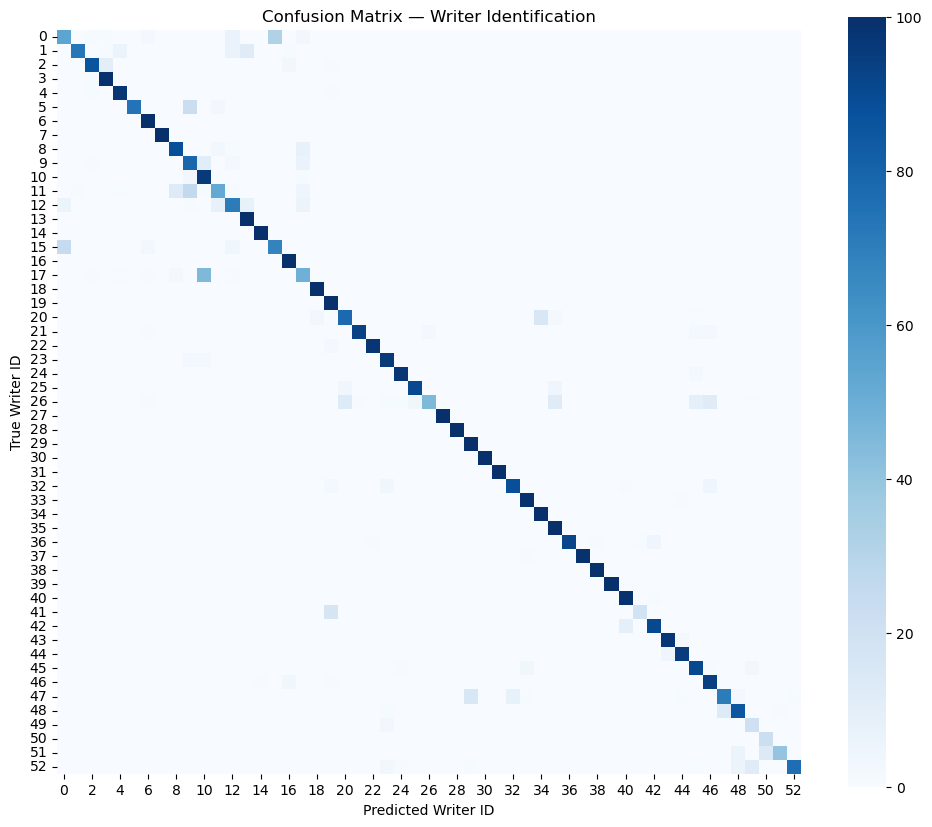

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_val_pad)
y_pred_cls = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_val_enc, y_pred_cls)
cm.shape

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", square=True, cbar=True)
plt.title("Confusion Matrix — Writer Identification")
plt.xlabel("Predicted Writer ID")
plt.ylabel("True Writer ID")
plt.show()

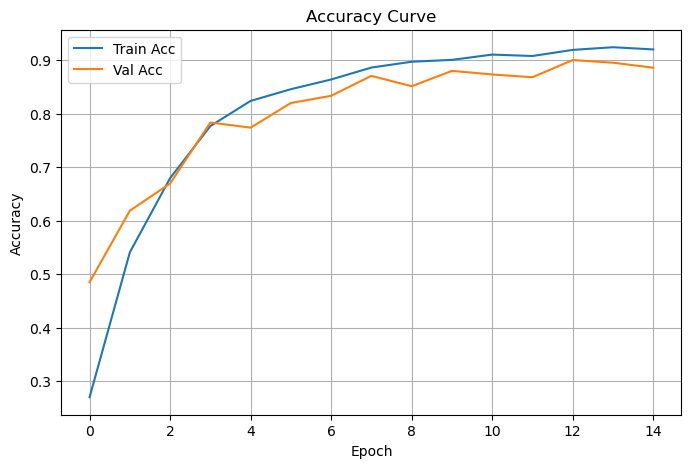

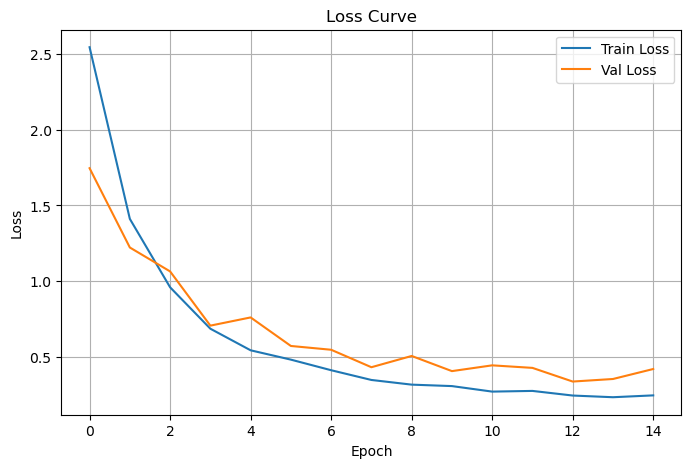

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
model.save("writer_bilstm_model.keras")